In [127]:
import pandas as pd
import numpy as np

In [128]:
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [129]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [130]:
features = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

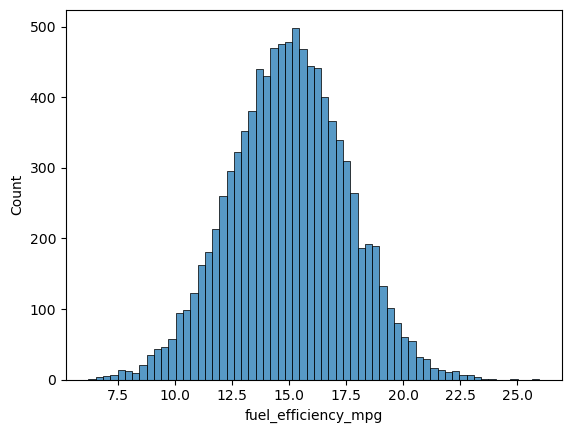

In [131]:
sns.histplot(df['fuel_efficiency_mpg'])

In [132]:
# Question 1

# There's one column with missing values. What is it?

df[features].isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
dtype: int64

In [133]:
df['horsepower'].median()

np.float64(149.0)

In [134]:
# Prepare and split the dataset

# Shuffle the dataset (the filtered one you created above), use seed 42.
# Split data in train/val/test sets, with 60%/20%/20% distribution.

np.random.seed(42)
idx = np.arange(len(df))
np.random.shuffle(idx)  # shuffling - very important!

# Used val_end = int(n * 0.8) as a cumulative index rather than computing a separate size, 
# which makes the slicing logic easier to follow
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)  # 60% + 20%

df_train = df.iloc[idx[:train_end]]
df_val = df.iloc[idx[train_end:val_end]]
df_test = df.iloc[idx[val_end:]]

df_train.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209


In [135]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [136]:
# Question 3

# We need to deal with missing values for the column from Q1.
# We have two options: fill it with 0 or with the mean of this variable.
# Try both options. For each, train a linear regression model without regularization using the code from the lessons.
# For computing the mean, use the training only!
# Use the validation dataset to evaluate the models and compare the RMSE of each option.
# Round the RMSE scores to 2 decimal digits using round(score, 2)
# Which option gives better RMSE?

#### Linear regression

In [137]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [138]:
def prepare_X(df, fill_value):
    df = df[features].copy()
    df.fillna(fill_value, inplace = True)
    X = df.values
    return X

#### fill NA using 0

In [139]:
X_train = prepare_X(df_train, fill_value = 0)
w_0, w = train_linear_regression(X_train, y_train)

In [140]:
X_val = prepare_X(df_val, fill_value = 0)
y_pred = w_0 + X_val @ w

In [141]:
def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

In [142]:
rmse(y_val, y_pred).round(2)

np.float64(0.52)

#### fill NA using mean

In [143]:
# Compute mean only from training data
train_mean = df_train[features].mean()
X_train = prepare_X(df_train, fill_value = train_mean)
w_0, w = train_linear_regression(X_train, y_train)

In [144]:
X_val = prepare_X(df_val, fill_value = train_mean)
y_pred = w_0 + X_val @ w

In [145]:
def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

In [146]:
rmse(y_val, y_pred).round(2)

np.float64(0.46)

In [147]:
# Question 4

# Now let's train a regularized linear regression.
# For this question, fill the NAs with 0.
# Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
# Use RMSE to evaluate the model on the validation dataset.
# Round the RMSE scores to 2 decimal digits.
# Which r gives the best RMSE?

In [148]:
X_train = prepare_X(df_train, fill_value = 0)
X_val = prepare_X(df_val, fill_value = 0)

### Linear regression with regularization

This implements Linear Regression with L2 Regularization (Ridge Regression)

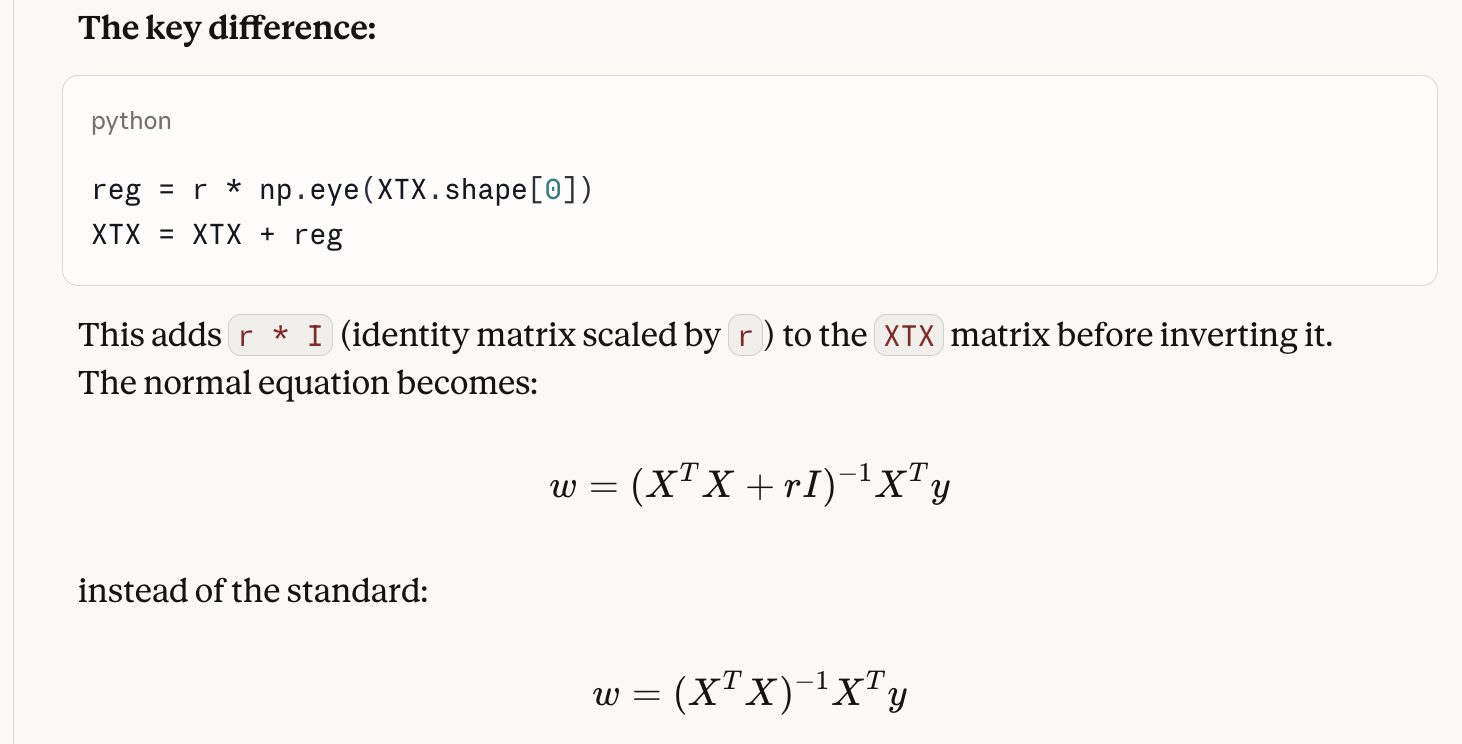

What regularization does:

- Penalizes large weights, keeping them small and preventing overfitting
- r=0.0 (the default) means no regularization — identical to your original function
- Higher r = stronger regularization = simpler model
- Also helps with numerical stability if XTX is singular or near-singular (which would cause np.linalg.inv to fail without regularization)

In [149]:

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [150]:

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r = r)
    y_pred = w_0 + X_val @ w
    score = rmse(y_val, y_pred).round(2)
    print(r, score)

0 0.52
0.01 0.52
0.1 0.52
1 0.52
5 0.52
10 0.52
100 0.52


In [151]:
# Question 5

# We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
# What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
# Round the result to 3 decimal digits (round(std, 3))

In [152]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    np.random.seed(seed)
    idx = np.arange(len(df))
    np.random.shuffle(idx)

    n = len(df)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)  # 60% + 20%
    
    df_train = df.iloc[idx[:train_end]]
    df_val = df.iloc[idx[train_end:val_end]]
    df_test = df.iloc[idx[val_end:]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values
    
    X_train = prepare_X(df_train, fill_value = 0)
    w_0, w = train_linear_regression(X_train, y_train)

    y_pred = w_0 + X_val @ w
    score = rmse(y_val, y_pred).round(2)
    scores.append(score)
    print(seed, score)

np.std(scores).round(3)   

0 3.61
1 3.64
2 3.61
3 3.71
4 3.61
5 3.61
6 3.54
7 3.59
8 3.6
9 3.6


np.float64(0.04)

In [154]:
# Question 6

# Split the dataset like previously, use seed 9.
# Combine train and validation datasets.
# Fill the missing values with 0 and train a model with r=0.001.
# What's the RMSE on the test dataset?

In [157]:
np.random.seed(9)
idx = np.arange(len(df))
np.random.shuffle(idx)

n = len(df)
train_end = int(n * 0.8)

df_train = df.iloc[idx[:train_end]]
df_test = df.iloc[idx[train_end:]]

y_train = df_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

X_train = prepare_X(df_train, fill_value = 0)
w_0, w = train_linear_regression_reg(X_train, y_train, r = 0.001)
X_test = prepare_X(df_test, fill_value = 0)

y_pred = w_0 + X_test @ w
score = rmse(y_test, y_pred).round(2)
score

np.float64(0.52)